In [2]:
import credentials
import twitter_settings  
import imp 
imp.reload(twitter_settings)
imp.reload(credentials)
from twitter_settings import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pprint import pprint
import spacy
import re
import time
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
import gensim
import gensim.corpora as corpora
from gensim.utils import simple_preprocess
from gensim.models import CoherenceModel
import mysql.connector
from wordcloud import WordCloud

import pyLDAvis
import pyLDAvis.gensim

%matplotlib inline
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)


In [3]:
stop_words=stopwords.words('english')
stop_words.extend(['netflix','disney','disney+','disneyplus'])
stop_words

['i',
 'me',
 'my',
 'myself',
 'we',
 'our',
 'ours',
 'ourselves',
 'you',
 "you're",
 "you've",
 "you'll",
 "you'd",
 'your',
 'yours',
 'yourself',
 'yourselves',
 'he',
 'him',
 'his',
 'himself',
 'she',
 "she's",
 'her',
 'hers',
 'herself',
 'it',
 "it's",
 'its',
 'itself',
 'they',
 'them',
 'their',
 'theirs',
 'themselves',
 'what',
 'which',
 'who',
 'whom',
 'this',
 'that',
 "that'll",
 'these',
 'those',
 'am',
 'is',
 'are',
 'was',
 'were',
 'be',
 'been',
 'being',
 'have',
 'has',
 'had',
 'having',
 'do',
 'does',
 'did',
 'doing',
 'a',
 'an',
 'the',
 'and',
 'but',
 'if',
 'or',
 'because',
 'as',
 'until',
 'while',
 'of',
 'at',
 'by',
 'for',
 'with',
 'about',
 'against',
 'between',
 'into',
 'through',
 'during',
 'before',
 'after',
 'above',
 'below',
 'to',
 'from',
 'up',
 'down',
 'in',
 'out',
 'on',
 'off',
 'over',
 'under',
 'again',
 'further',
 'then',
 'once',
 'here',
 'there',
 'when',
 'where',
 'why',
 'how',
 'all',
 'any',
 'both',
 'each

In [4]:
def connect_db():
    mydb = mysql.connector.connect(
        host="localhost",
        user="root",
        password="*******",
        database="TwitterDB",
        auth_plugin='mysql_native_password',
        charset='utf8'  
    )
    
    return mydb

def close_db(mydb):
    mydb.close()

In [5]:
## Open db connection
mydb = connect_db()
netflix_query = "SELECT id_str, created_at, track, text, polarity, compound_score ,negative_score ,positive_score ,neutral_score, hashtags, user_location FROM {} where track like 'Netflix' order by created_at desc" \
                     .format(twitter_settings.HISTORY_TABLE_NAME)
netflix_tweets_df = pd.read_sql(netflix_query,con=mydb)
netflix_tweets_df["created_at"]=netflix_tweets_df.created_at.astype(np.datetime64)
close_db(mydb)
netflix_tweets_df#.head()

,id_str,created_at,track,text,polarity,compound_score,negative_score,positive_score,neutral_score,hashtags,user_location
0,1199710425379684352,2019-11-27 10:23:49,Netflix,THE IRISHMAN is now finally streaming on Netfl...,0,0.0000,0.000,0.000,1.000,[],"Missoula, MT"
1,1199710035577839622,2019-11-27 10:22:16,Netflix,hello i need the third season or anne with a e...,0,0.0000,0.000,0.000,1.000,[],None
2,1199709953545703430,2019-11-27 10:21:57,Netflix,Because the people who can save it really do h...,1,0.1868,0.083,0.108,0.809,[],None
3,1199709579984150529,2019-11-27 10:20:28,Netflix,THE IRISHMAN is on Netflix today You should ab...,1,0.4588,0.000,0.120,0.880,[],Earth
4,1199709435116965889,2019-11-27 10:19:53,Netflix,im still not over this can someone give me a m...,0,0.0000,0.000,0.000,1.000,[],cha . cosmic atte
5,1199709109647396864,2019-11-27 10:18:35,Netflix,Rainy days are perfect for sad music and binge...,1,0.0772,0.243,0.204,0.552,[],None
6,1199708568217432064,2019-11-27 10:16:26,Netflix,THE IRISHMAN is now finally streaming on Netfl...,0,0.0000,0.000,0.000,1.000,[],"Gamehendge, NY"
7,1199708314566823938,2019-11-27 10:15:26,Netflix,Omg i feel the same I sadly still waste hours ...,-1,-0.4215,0.167,0.000,0.833,[],Italy
8,1199708274871848961,2019-11-27 10:15:16,Netflix,The bread and circuses or in the modern sense ...,0,0.0000,0.000,0.000,1.000,[],"Tigard, OR"
9,1199708158328889344,2019-11-27 10:14:49,Netflix,whispers pitch it to Netflix or SyFy,0,0.0000,0.000,0.000,1.000,[],"New York, NY"


In [6]:
tweets_list = netflix_tweets_df['text'].values.tolist()
tweets_list

['THE IRISHMAN is now finally streaming on Netflix Once you ve seen it or if you really don t give a cuss about spoilers rea',
 'hello i need the third season or anne with a e on netflix RIGHT NOW',
 'Because the people who can save it really do have no brains when it comes to this show Or Netflix has something in a c',
 'THE IRISHMAN is on Netflix today You should absolutely watch it if you have any interest in Scorsese gangster movies or',
 'im still not over this can someone give me a movie or a series or SOMETHING netflix marvel',
 'Rainy days are perfect for sad music and binge watching Netflix or Disney',
 'THE IRISHMAN is now finally streaming on Netflix Once you ve seen it or if you really don t give a cuss about spo',
 'Omg i feel the same I sadly still waste hours on Netflix and youtube but at the end of the day',
 'The bread and circuses or in the modern sense the pizza and Netflix have them distrac',
 'whispers pitch it to Netflix or SyFy',
 'So bighit unfollowed Netflix Ko

## Tokenization words and clean up text

In [7]:
def tweets_to_words(tweets):
    for tweet in tweets:
        yield(gensim.utils.simple_preprocess(str(tweet),deacc=True))
tweet_words = list(tweets_to_words(tweets_list))
print(tweet_words)

[['the', 'irishman', 'is', 'now', 'finally', 'streaming', 'on', 'netflix', 'once', 'you', 've', 'seen', 'it', 'or', 'if', 'you', 'really', 'don', 'give', 'cuss', 'about', 'spoilers', 'rea'], ['hello', 'need', 'the', 'third', 'season', 'or', 'anne', 'with', 'on', 'netflix', 'right', 'now'], ['because', 'the', 'people', 'who', 'can', 'save', 'it', 'really', 'do', 'have', 'no', 'brains', 'when', 'it', 'comes', 'to', 'this', 'show', 'or', 'netflix', 'has', 'something', 'in'], ['the', 'irishman', 'is', 'on', 'netflix', 'today', 'you', 'should', 'absolutely', 'watch', 'it', 'if', 'you', 'have', 'any', 'interest', 'in', 'scorsese', 'gangster', 'movies', 'or'], ['im', 'still', 'not', 'over', 'this', 'can', 'someone', 'give', 'me', 'movie', 'or', 'series', 'or', 'something', 'netflix', 'marvel'], ['rainy', 'days', 'are', 'perfect', 'for', 'sad', 'music', 'and', 'binge', 'watching', 'netflix', 'or', 'disney'], ['the', 'irishman', 'is', 'now', 'finally', 'streaming', 'on', 'netflix', 'once', 'you

## Create bigram and trigram models

In [8]:
bigram = gensim.models.Phrases(tweet_words,min_count=5,threshold=100) # higher threshold fewer phrases
trigram = gensim.models.Phrases(bigram[tweet_words],threshold=100)

bigram_model = gensim.models.phrases.Phraser(bigram)
trigram_model = gensim.models.phrases.Phraser(trigram)

print(trigram_model[bigram_model[tweet_words[0]]])

['the', 'irishman', 'is', 'now', 'finally', 'streaming', 'on', 'netflix', 'once', 'you', 've', 'seen', 'it', 'or', 'if', 'you', 'really', 'don', 'give', 'cuss', 'about', 'spoilers', 'rea']


## Remove stopwords, lemmatization

In [9]:
def remove_stopwords(tweets):
    return [[word for word in simple_preprocess(str(single_tweet)) 
             if word not in stop_words] for single_tweet in tweets]

def make_bigrams(tweets):
    return [bigram_model[single_tweet] for single_tweet in tweets]

def make_trigrams(tweets):
    return [trigram_model[single_tweet] for single_tweet in tweets]

def lemmatization(tweets, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV']):
    """https://spacy.io/api/annotation"""
    tweets_out = []
    for tweet in tweets:
        doc = nlp(" ".join(tweet)) 
        tweets_out.append([token.lemma_ for token in doc if token.pos_ in allowed_postags])
    return tweets_out

In [10]:
# Remove Stop Words
tweet_words_nostops = remove_stopwords(tweet_words)

# Form Bigrams
tweet_words_bigrams = make_bigrams(tweet_words_nostops)

# Initialize spacy 'en' model, keeping only tagger component (for efficiency)
# python3 -m spacy download en
nlp = spacy.load('en', disable=['parser', 'ner'])

# Do lemmatization keeping only noun, adj, vb, adv
tweet_lemmatized = lemmatization(tweet_words_bigrams, allowed_postags=['NOUN', 'ADJ', 'VERB', 'ADV'])

print(tweet_lemmatized[:1])

[['finally', 'stream', 'see', 'really', 'give']]


## Create dictionary and corpus for Topic Modelling

In [11]:
# Create Dictionary
tweetid2word = corpora.Dictionary(tweet_lemmatized)

# Create Corpus
tweets = tweet_lemmatized

# Term Document Frequency
corpus = [tweetid2word.doc2bow(tweet) for tweet in tweets]

# View
print(corpus[:1])

[[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1)]]


In [12]:
tweetid2word[0]

'finally'

In [13]:
# Human readable format of corpus (term-frequency)
[[(tweetid2word[id], freq) for id, freq in cp] for cp in corpus[:1]]

[[('finally', 1), ('give', 1), ('really', 1), ('see', 1), ('stream', 1)]]

In [14]:
def generate_word_cloud_text(tweets):
    text = ' '
    for tweet in tweets:
         # Converts each token into lowercase 
        for i in range(len(tweet)): 
            tweet[i] = tweet[i].lower() 

        for word in tweet: 
            text = text + word + ' '
            
        wc = WordCloud(max_words= 100,
                          width = 744, 
                          height = 544,
                          background_color ='white',
                          stopwords=stop_words, 
                          contour_width=3, 
                          contour_color='steelblue',
                          min_font_size = 10).generate(text) 
    return wc

(-0.5, 743.5, 543.5, -0.5)

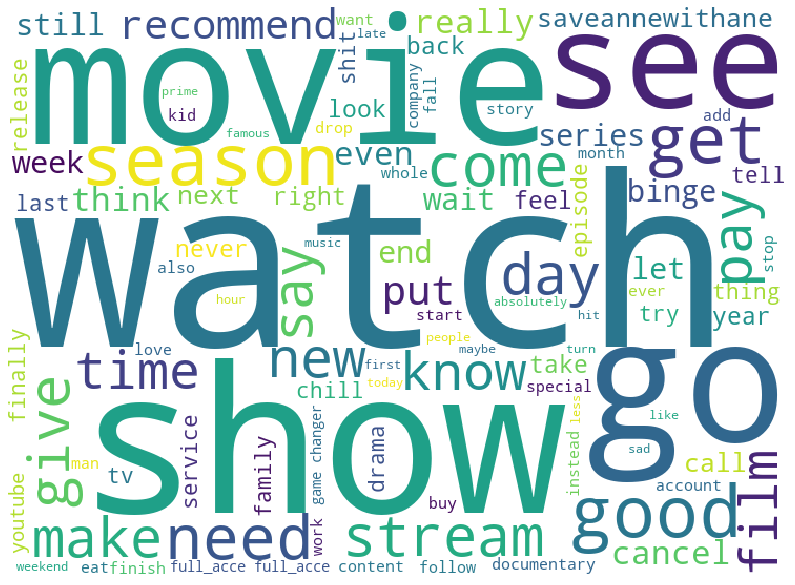

In [15]:
wordcloud_text = generate_word_cloud_text(tweets)
# wordcloud(corpus, min.freq=2, max.words = 150, random.order = TRUE, col = pal)
plt.figure(figsize = (14, 14)) 
plt.imshow(wordcloud_text) 
plt.axis("off")
#plt.savefig('./images/twitter_wordcloud.png')

## Build Topic Model

In [17]:
# Build LDA model
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                           id2word=tweetid2word,
                                           num_topics=20, 
                                           random_state=100,
                                           update_every=1,
                                           chunksize=100,
                                           passes=10,
                                           alpha='auto',
                                           per_word_topics=True)

# Print the Keyword in the 10 topics
pprint(lda_model.print_topics())
tweet_lda = lda_model[corpus]

[(0,
  '0.062*"use" + 0.061*"tv" + 0.036*"youtube" + 0.011*"interact" + '
  '0.011*"catch" + 0.011*"hear" + 0.011*"issue" + 0.011*"agree" + '
  '0.011*"longer" + 0.011*"newspaper"'),
 (1,
  '0.126*"pay" + 0.066*"year" + 0.045*"binge" + 0.029*"life" + 0.028*"music" + '
  '0.028*"sad" + 0.022*"perfect" + 0.018*"day" + 0.018*"co" + 0.016*"watch"'),
 (2,
  '0.107*"look" + 0.075*"end" + 0.063*"right" + 0.043*"late" + 0.042*"drama" + '
  '0.019*"world" + 0.009*"pour" + 0.009*"sur" + 0.009*"piece" + '
  '0.009*"fucking"'),
 (3,
  '0.278*"movie" + 0.192*"good" + 0.047*"horror" + 0.045*"recommend" + '
  '0.001*"junk" + 0.001*"food" + 0.001*"straight" + 0.001*"man" + 0.001*"mind" '
  '+ 0.001*"cute"'),
 (4,
  '0.193*"get" + 0.068*"service" + 0.039*"see" + 0.027*"date" + 0.024*"first" '
  '+ 0.015*"btw" + 0.015*"nex" + 0.015*"wait" + 0.015*"deserve" + '
  '0.015*"course"'),
 (5,
  '0.115*"day" + 0.099*"really" + 0.042*"let" + 0.027*"find" + 0.022*"social" '
  '+ 0.019*"finally" + 0.010*"touch" + 

In [18]:
# Compute Perplexity
print('\nPerplexity: ', lda_model.log_perplexity(corpus))  # a measure of how good the model is. lower the better.

# Compute Coherence Score
coherence_model_lda = CoherenceModel(model=lda_model, texts=tweet_lemmatized, 
                                     dictionary=tweetid2word, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print('\nCoherence Score: ', coherence_lda)


Perplexity:  -14.857256893169335

Coherence Score:  0.4192698314707532


In [22]:
corpus

[[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1)],
 [(5, 1), (6, 1), (7, 1), (8, 1)],
 [(2, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1)],
 [(14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1)],
 [(1, 1), (17, 1), (21, 1), (22, 1), (23, 1), (24, 1)],
 [(20, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 1), (30, 1)],
 [(0, 1), (1, 1), (2, 1), (3, 1), (4, 1)],
 [(24, 1),
  (26, 1),
  (31, 1),
  (32, 1),
  (33, 1),
  (34, 1),
  (35, 1),
  (36, 1),
  (37, 1)],
 [(38, 1), (39, 1), (40, 1), (41, 1), (42, 1), (43, 1)],
 [(44, 1), (45, 1), (46, 1)],
 [(47, 1), (48, 1), (49, 1), (50, 1), (51, 1), (52, 1)],
 [(31, 1), (53, 1), (54, 1), (55, 1)],
 [(3, 1), (56, 1)],
 [(17, 1), (57, 1)],
 [(20, 2), (58, 1), (59, 1), (60, 1)],
 [(5, 1)],
 [(54, 1), (61, 1), (62, 1), (63, 1), (64, 1)],
 [(17, 1), (19, 1), (20, 1), (65, 1), (66, 1)],
 [(21, 1), (67, 1), (68, 1), (69, 1)],
 [(70, 1), (71, 1), (72, 1), (73, 1), (74, 1)],
 [(7, 2), (13, 1), (32, 1), (75, 1), (76, 1), (77, 1), (78, 1), (79, 1)],
 [(13

## Make dataframe of topic words and weights

In [187]:
lda_topics_list = lda_model.print_topics()
col_list=[]
for i in range(0,len(lda_topics_list)):
    colname1 = 'Topic_' + str(i) + '_words'
    colname2 = 'Topic_' + str(i) + '_weights'
    col_list.append(colname1)
    col_list.append(colname2)
topic_df = pd.DataFrame(columns=col_list)
for i in range(0,len(lda_topics_list)):
    topics_words_list = lda_topics_list[i][1].split('+')
    weights_list=[]
    topicword_list=[]
    for word in topics_words_list:
        weight = float(word.split('*')[0].strip())
        topicword = word.split('*')[1].strip().strip('"')
        weights_list.append(weight)
        topicword_list.append(topicword)
    topic_df['Topic_' + str(i) + '_words'] = pd.Series(topicword_list)
    topic_df['Topic_' + str(i) + '_weights'] = pd.Series(weights_list)
topic_df

,Topic_0_words,Topic_0_weights,Topic_1_words,Topic_1_weights,Topic_2_words,Topic_2_weights,Topic_3_words,Topic_3_weights,Topic_4_words,Topic_4_weights,Topic_5_words,Topic_5_weights,Topic_6_words,Topic_6_weights,Topic_7_words,Topic_7_weights,Topic_8_words,Topic_8_weights,Topic_9_words,Topic_9_weights,Topic_10_words,Topic_10_weights,Topic_11_words,Topic_11_weights,Topic_12_words,Topic_12_weights,Topic_13_words,Topic_13_weights,Topic_14_words,Topic_14_weights,Topic_15_words,Topic_15_weights,Topic_16_words,Topic_16_weights,Topic_17_words,Topic_17_weights,Topic_18_words,Topic_18_weights,Topic_19_words,Topic_19_weights
0,come,0.147,watch,0.351,make,0.174,chill,0.116,season,0.097,show,0.224,direct,0.002,account,0.133,pay,0.225,go,0.124,s,0.166,even,0.113,say,0.175,step,0.034,want,0.104,need,0.155,stream,0.118,get,0.221,direct,0.002,sign,0.082
1,fall,0.043,be,0.098,take,0.066,time,0.072,movie,0.086,good,0.116,major,0.002,premium,0.044,man,0.094,watch,0.050,watch,0.088,day,0.113,cancel,0.046,end,0.034,full_acce,0.076,know,0.118,stop,0.089,think,0.056,major,0.002,call,0.063
2,movie,0.034,go,0.051,thing,0.055,star,0.024,look,0.066,film,0.088,catalogue,0.002,really,0.031,certain,0.070,changer,0.049,see,0.066,put,0.102,movie,0.025,content,0.034,release,0.037,back,0.048,amazing,0.043,add,0.040,catalogue,0.002,finish,0.053
3,drop,0.028,recommendation,0.026,boy,0.028,bottle,0.012,stream,0.059,new,0.055,documentary,0.002,upcoming,0.014,love,0.034,game,0.049,full,0.065,original,0.068,actually,0.024,become,0.034,official,0.024,bring,0.025,spend,0.023,important,0.029,documentary,0.002,last,0.039
4,week,0.028,movie,0.024,cool,0.012,water,0.012,free,0.049,girl,0.029,performance,0.002,thriller,0.014,lose,0.021,people,0.023,next,0.050,straight,0.029,ray,0.024,almost,0.015,series,0.024,movie,0.025,addition,0.012,rid,0.024,performance,0.002,year,0.035
5,new,0.020,way,0.013,see,0.012,wine,0.012,switch,0.049,also,0.023,kill,0.002,survival,0.014,back,0.009,special,0.023,door,0.020,future,0.019,part,0.024,bit,0.015,final,0.024,recommend,0.025,imaginative,0.012,welcome,0.013,kill,0.002,federal,0.025
6,burlesque,0.020,time,0.008,hero,0.012,hot,0.012,download,0.049,turn,0.019,nearly,0.002,pro,0.014,text,0.009,co,0.010,try,0.020,wait,0.018,spotify,0.024,see,0.015,work,0.024,background,0.011,animation,0.012,kid,0.013,nearly,0.002,taxis,0.025
7,money,0.020,room,0.008,super,0.012,night,0.012,buy,0.032,yet,0.019,ban,0.002,fortnite,0.014,youtube,0.009,adaptation,0.010,better,0.020,name,0.015,be,0.016,concern,0.015,random,0.020,cuddly,0.011,really,0.012,spinoff,0.001,ban,0.002,pay,0.025
8,right,0.020,projector,0.008,great,0.012,role,0.012,service,0.024,dinosaur,0.008,harder,0.002,title,0.014,really,0.009,victor,0.010,world,0.009,whole,0.015,talk,0.010,trust,0.015,unmigrated,0.020,window,0.011,story,0.012,wish,0.001,harder,0.002,income,0.025
9,film,0.020,countless,0.008,classroom,0.012,teen,0.012,trailer,0.024,mad,0.008,beautiful,0.002,unchecked,0.014,pause,0.009,happy,0.010,western,0.009,list,0.008,sully,0.010,provide,0.015,semi,0.020,rating,0.011,spen,0.012,pretty,0.001,beautiful,0.002,company,0.025


In [188]:
max(topic_df)

'Topic_9_words'

## Dominant topic in each tweet

In [1]:
corpus

NameError: name 'corpus' is not defined

In [205]:
def format_topics_sentences(ldamodel=lda_model, corpus=corpus, texts=tweets_list):
    # Init output
    sent_topics_df = pd.DataFrame()

    # Get main topic in each document
    for i, row in enumerate(ldamodel[corpus]):
        row = sorted(row[0], key=lambda x: x[1], reverse=True)
        # Get the Dominant topic, Perc Contribution and Keywords for each document
        for j, (topic_num, prop_topic) in enumerate(row):
            if j == 0:  # => dominant topic
                wp = ldamodel.show_topic(topic_num)
                topic_keywords = ", ".join([word for word, prop in wp])
                sent_topics_df = sent_topics_df.append(pd.Series([int(topic_num), round(prop_topic,4), topic_keywords]), ignore_index=True)
            else:
                break
    sent_topics_df.columns = ['Dominant_Topic', 'Perc_Contribution', 'Topic_Keywords']

    # Add original text to the end of the output
    contents = pd.Series(texts)
    sent_topics_df = pd.concat([sent_topics_df, contents], axis=1)
    return(sent_topics_df)


df_topic_sents_keywords = format_topics_sentences(ldamodel=lda_model, corpus=corpus, texts=tweets_list)

# Format
df_dominant_topic = df_topic_sents_keywords.reset_index()
df_dominant_topic.columns = ['Document_No', 'Dominant_Topic', 'Topic_Perc_Contrib', 'Keywords', 'Text']

# Show
df_dominant_topic.head(10)

,Document_No,Dominant_Topic,Topic_Perc_Contrib,Keywords,Text
0,0,14.0,0.8915,"want, full_acce, release, official, series, fi...",SORTEO RANDOM SEMI FULL ACCES UNMIGRATED FULL ...
1,1,16.0,0.5782,"stream, stop, amazing, spend, addition, imagin...",Xadia awaits The Dragon Prince season 3 is NOW...
2,2,10.0,0.6173,"s, watch, see, full, next, door, try, better, ...",I didnt know the full story of Ivan the Terrib...
3,3,0.0,0.6078,"come, fall, movie, drop, week, new, burlesque,...",netflix and chill hulu and woohoo amazon prime...
4,4,9.0,0.8045,"go, watch, changer, game, people, special, co,...",Happy Birthday to The Black Kaiser himself Fro...
5,5,11.0,0.7491,"even, day, put, original, straight, future, wa...",netflix originals are great until you binge wa...
6,6,12.0,0.8057,"say, cancel, movie, actually, ray, part, spoti...",fenty girl its 20 if its hard they can cancel ...
7,7,9.0,0.5158,"go, watch, changer, game, people, special, co,...",Netflix had to go
8,8,3.0,0.8763,"chill, time, star, bottle, water, wine, hot, n...",Friday night chilling Netflix hot water bottle...
9,9,14.0,0.8779,"want, full_acce, release, official, series, fi...",SORTEO RANDOM SEMI FULL ACCES UNMIGRATED FULL ...


## Most representative topic for each tweet

In [206]:
# Group top 5 sentences under each topic
sent_topics_sorteddf_mallet = pd.DataFrame()

sent_topics_outdf_grpd = df_topic_sents_keywords.groupby('Dominant_Topic')

for i, grp in sent_topics_outdf_grpd:
    sent_topics_sorteddf_mallet = pd.concat([sent_topics_sorteddf_mallet, 
                                             grp.sort_values(['Perc_Contribution'], ascending=[0]).head(1)], 
                                            axis=0)

# Reset Index    
sent_topics_sorteddf_mallet.reset_index(drop=True, inplace=True)

# Format
sent_topics_sorteddf_mallet.columns = ['Topic_Num', "Topic_Perc_Contrib", "Keywords", "Text"]

# Show
sent_topics_sorteddf_mallet.head()

,Topic_Num,Topic_Perc_Contrib,Keywords,Text
0,0.0,0.8923,"come, fall, movie, drop, week, new, burlesque,...",From hot to toxic yoga a new Netflix film docu...
1,1.0,0.8101,"watch, be, go, recommendation, movie, way, tim...",when that kpop boy have his own projector in h...
2,2.0,0.8773,"make, take, thing, boy, cool, see, hero, super...",Have you seen The Boys yet It s great Cool tak...
3,3.0,0.8763,"chill, time, star, bottle, water, wine, hot, n...",Friday night chilling Netflix hot water bottle...
4,4.0,0.7667,"season, movie, look, stream, free, switch, dow...",Now streaming on Netflix K ON Seasons 1 amp 2 ...


## Topic 0

In [189]:
topic_value='0'
topic_visual_df = topic_df[['Topic_0_words','Topic_0_weights']].reset_index(drop=True)
#topic_visual_df.rename(columns={'Topic_0_words':'word','Topic_0_weights':'weight'},inplace=True)
topic_visual_df

,Topic_0_words,Topic_0_weights
0,come,0.147
1,fall,0.043
2,movie,0.034
3,drop,0.028
4,week,0.028
5,new,0.020
6,burlesque,0.020
7,money,0.020
8,right,0.020
9,film,0.020


In [190]:
topic_visual_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
Topic_0_words      10 non-null object
Topic_0_weights    10 non-null float64
dtypes: float64(1), object(1)
memory usage: 240.0+ bytes


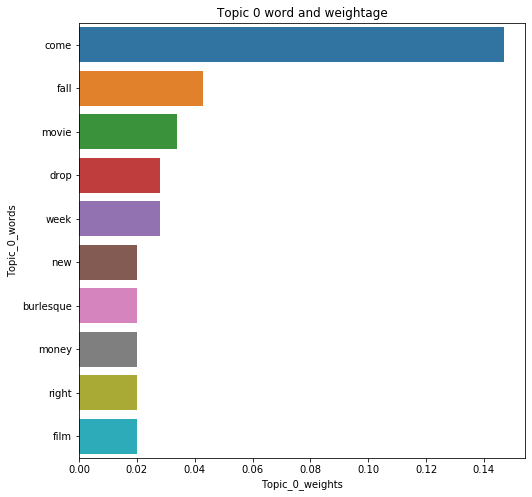

In [192]:
plt.figure(figsize=(8,8))
plt.title('Topic {0} word and weightage'.format(topic_value))
sns.barplot(y='Topic_0_words',x='Topic_0_weights',data=topic_visual_df);

## Select row1 being the heighest weightage row from all topics

In [100]:
row1 = topic_df.loc[0]
print(type(row1))
row1

<class 'pandas.core.series.Series'>


Topic_0_words          come
Topic_0_weights       0.147
Topic_1_words         watch
Topic_1_weights       0.351
Topic_2_words          make
Topic_2_weights       0.174
Topic_3_words         chill
Topic_3_weights       0.116
Topic_4_words        season
Topic_4_weights       0.097
Topic_5_words          show
Topic_5_weights       0.224
Topic_6_words        direct
Topic_6_weights       0.002
Topic_7_words       account
Topic_7_weights       0.133
Topic_8_words           pay
Topic_8_weights       0.225
Topic_9_words            go
Topic_9_weights       0.124
Topic_10_words            s
Topic_10_weights      0.166
Topic_11_words         even
Topic_11_weights      0.113
Topic_12_words          say
Topic_12_weights      0.175
Topic_13_words         step
Topic_13_weights      0.034
Topic_14_words         want
Topic_14_weights      0.104
Topic_15_words         need
Topic_15_weights      0.155
Topic_16_words       stream
Topic_16_weights      0.118
Topic_17_words          get
Topic_17_weights    

In [123]:
topicwords_list=[]
topicwords_weight_list=[]
for i in range(0,len(lda_topics_list)):
    word_subset = row1['Topic_'+str(i)+'_words'].values[0]
    topicwords_list.append(word_subset)
    weight_subset = row1['Topic_'+str(i)+'_weights'].values[0]
    topicwords_weight_list.append(weight_subset)
subtopic_df = pd.DataFrame(columns=['word','weight'])
subtopic_df['word'] = topicwords_list
subtopic_df['weight'] = topicwords_weight_list
subtopic_df = subtopic_df.sort_values(by='weight',ascending=False).reset_index(drop=True)
subtopic_df

,word,weight
0,watch,0.351
1,pay,0.225
2,show,0.224
3,get,0.221
4,say,0.175
5,make,0.174
6,s,0.166
7,need,0.155
8,come,0.147
9,account,0.133


In [180]:
subtopic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
word      20 non-null object
weight    20 non-null float64
dtypes: float64(1), object(1)
memory usage: 400.0+ bytes


In [124]:
subtopic_df['word'][0]

'watch'

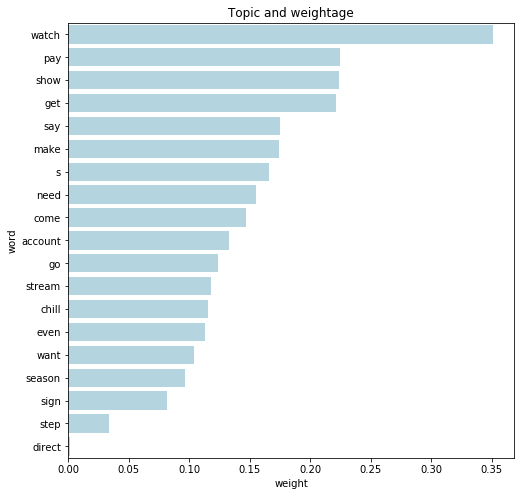

In [174]:
plt.figure(figsize=(8,8))
plt.title('Topic and weightage')
sns.barplot(y='word',x='weight',data=subtopic_df,color='lightblue');

## check for the tweets where most weighted topic has occured

In [138]:
netflix_subset_df=netflix_tweets_df[netflix_tweets_df['text'].str.contains(subtopic_df['word'][0])]
print('total no of tweets with word "{0}": {1}'.format(subtopic_df['word'][0],netflix_subset_df.shape[0]))
netflix_subset_df

total no of tweets with word "watch": 29


,id_str,created_at,track,text,polarity,compound_score,negative_score,positive_score,neutral_score,hashtags,user_location
2,1198028363551641600,2019-11-22 18:59:54,Netflix,I didnt know the full story of Ivan the Terrib...,-1,-0.8462,0.280,0.000,0.720,[],"Washington, DC"
5,1198028348473004033,2019-11-22 18:59:51,Netflix,netflix originals are great until you binge wa...,1,0.6249,0.000,0.141,0.859,[],None
18,1198028289232769025,2019-11-22 18:59:37,Netflix,when that kpop boy have his own projector in h...,0,0.0000,0.000,0.000,1.000,[],"mako, they/them"
28,1198028177811103744,2019-11-22 18:59:10,Netflix,So I ve been watching alot of movies on netfli...,0,0.0000,0.000,0.000,1.000,[],None
37,1198028093941829632,2019-11-22 18:58:50,Netflix,Netflix does not show weekly episodes until th...,1,0.5106,0.000,0.163,0.837,[],"Manhattan, NY"
38,1197665994937917440,2019-11-21 18:59:59,Netflix,It makes me sad that my only way of watching t...,-1,-0.4767,0.114,0.000,0.886,[],None
39,1197665991695753217,2019-11-21 18:59:58,Netflix,So DragRaceUK finished think I m gonna binge w...,0,0.0000,0.000,0.000,1.000,['DragRaceUK'],United Kingdom
46,1197665946426474496,2019-11-21 18:59:47,Netflix,No way im watching that kay haha My kids would...,1,0.2023,0.081,0.110,0.809,[],Cassiopeia
47,1197665927480979457,2019-11-21 18:59:43,Netflix,Im in bed watching Netflix,0,0.0000,0.000,0.000,1.000,[],"Charlotte , NC"
58,1197665875488387072,2019-11-21 18:59:30,Netflix,The 30 for 30 podcast was just wow but this do...,1,0.7607,0.000,0.221,0.779,[],"Texas, USA"


## check for the polarity of tweets where most weighted topic has occured

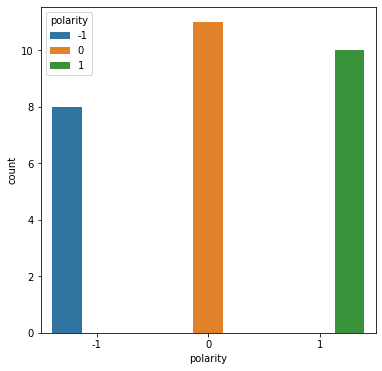

In [136]:
plt.figure(figsize=(6,6))
sns.countplot(x='polarity',data=netflix_subset_df,hue='polarity');
#plt.xticks(['negative','neutral','positive'])

In [144]:
netflix_short_tweets_df = netflix_tweets_df.copy()
netflix_short_tweets_df["tweet_len"] = netflix_tweets_df['text'].apply(lambda x: len(x.split()))
netflix_short_tweets_df

,id_str,created_at,track,text,polarity,compound_score,negative_score,positive_score,neutral_score,hashtags,user_location,tweet_len
0,1198028375899693056,2019-11-22 18:59:57,Netflix,SORTEO RANDOM SEMI FULL ACCES UNMIGRATED FULL ...,0,0.0000,0.000,0.000,1.000,[],Nederland,15
1,1198028367456604166,2019-11-22 18:59:55,Netflix,Xadia awaits The Dragon Prince season 3 is NOW...,1,0.2225,0.000,0.119,0.881,['TheDragonPrince'],Chile,13
2,1198028363551641600,2019-11-22 18:59:54,Netflix,I didnt know the full story of Ivan the Terrib...,-1,-0.8462,0.280,0.000,0.720,[],"Washington, DC",23
3,1198028356266184708,2019-11-22 18:59:53,Netflix,netflix and chill hulu and woohoo amazon prime...,1,0.9062,0.000,0.406,0.594,[],None,20
4,1198028349320257538,2019-11-22 18:59:51,Netflix,Happy Birthday to The Black Kaiser himself Fro...,1,0.5719,0.000,0.171,0.829,[],None,16
5,1198028348473004033,2019-11-22 18:59:51,Netflix,netflix originals are great until you binge wa...,1,0.6249,0.000,0.141,0.859,[],None,25
6,1198028345218338818,2019-11-22 18:59:50,Netflix,fenty girl its 20 if its hard they can cancel ...,1,0.3612,0.152,0.175,0.673,[],Deep End,16
7,1198028343582642183,2019-11-22 18:59:50,Netflix,Netflix had to go,0,0.0000,0.000,0.000,1.000,[],South FL,4
8,1198028339061182464,2019-11-22 18:59:48,Netflix,Friday night chilling Netflix hot water bottle...,0,-0.0258,0.068,0.000,0.932,[],"Hackney, London",12
9,1198028338301935616,2019-11-22 18:59:48,Netflix,SORTEO RANDOM SEMI FULL ACCES UNMIGRATED FULL ...,0,0.0000,0.000,0.000,1.000,[],"Apolo, Jeffy, Sino, Dhylam",15


## LDA Mallet Model

In [204]:
# import os

# os.environ['MALLET_HOME'] = '/Users/vidhu/GA-classes/Vidhu-Capstone/Twitter/MediaTwitter/mallet-2.0.8/'
# mallet_path = './mallet-2.0.8/bin/mallet'
# ldamallet = gensim.models.wrappers.LdaMallet(mallet_path,corpus=corpus,
#                                            id2word=tweetid2word,num_topics=20)